# 1.Buisness understanding

In this project, I analyze what factors influence developer salaries using the StackOverflow survery dataset.

## Buisness Questions:
1. What features influence salary the most?
2. Are there surprising patterns in the data?
3. How accurate is the prediction model?
4. What happens in a predicitve scenario?

In [1]:
#imports and setup
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2. Data Understanding

The dataset contains survey responses from developers including salary, education level and experience.
In this step, the data is loaded and explored.

In [2]:
# load the dataset
url = 'https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv'
df = pd.read_csv(url, low_memory=False)

# Preview
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [3]:
# Overview of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


# 3. Data Preparation

In this step, relevant columns are selected, missing values are handled and categorical variables are converted into numerical format

In [4]:
# Select relevant columns
df = df[["ConvertedCompYearly", "YearsCode","EdLevel", "WorkExp"]]

# Rename columns for clarity 
df = df.rename(columns={"ConvertedCompYearly": "Salary",
                        "YearsCode": "Experience", 
                        "EdLevel":"Education", 
                        "WorkExp":"WorkExperience"})

In [5]:
# Convert experience to numeric
df["Experience"] = pd.to_numeric(df["Experience"], errors = "coerce")

In [6]:
# Convert categorical variable into numeric (one-hot encoding)
df = pd.get_dummies(df, columns=["Education"], drop_first=True)

Missing values were removed from the dataset to ensure that the machine learning model can train properly.

The dataset contains over 49,000 responsesm so removing rows with missing values still leaves a large amount of data for analysis.

This approach was preferred over imputing values because variables such as salary and experience cannot be reliably estimated.

In [7]:
# Remove missing values
print("Rows before cleaning:", len(df))
df = df.dropna()
print("Rows after cleaning:", len(df))


Rows before cleaning: 49191
Rows after cleaning: 23400


## 4. Data Analysis

The relationship between experience and salary is explored using a scatterplot.

In [8]:
#function for experience-salary plot
def plot_scatter_salary_vs_experience(df, title):
    """Create a scatterplot showing the relationship between experience and salary.
    Parameters:
    df (DataFrame): cleaned dataset
    title (str): title of the plot
    """
    plt.figure(figsize=(6,4))
    sns.scatterplot(x="Experience", y="Salary", data=df)
    plt.title(title)
    plt.show()

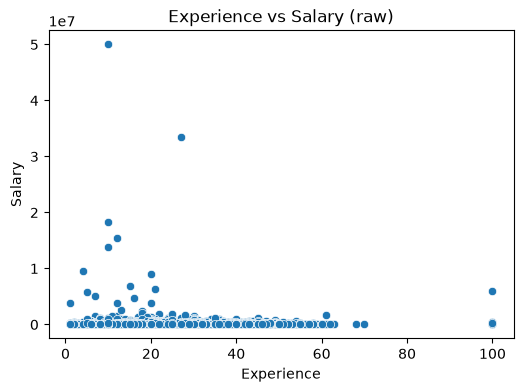

In [9]:
# First scatterplot
plot_scatter_salary_vs_experience(df, "Experience vs Salary (raw)")

Outliers with unrealistic salary values must be removed to improve analysis and model performance.

In [10]:
# Remove outliners
df = df[df["Salary"]<500000] #max 500k salary
df = df[df["Experience"] < 50] #max 50 years experience

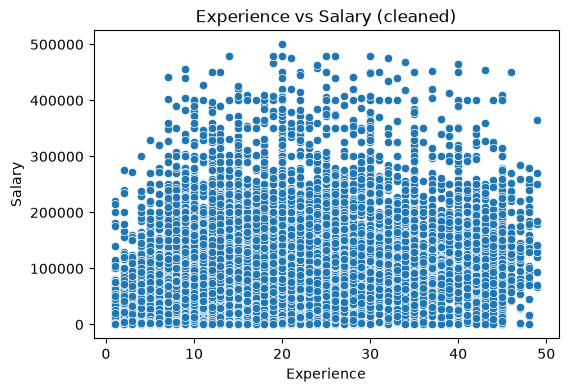

In [11]:
# Cleaned scatterplot
plot_scatter_salary_vs_experience(df, "Experience vs Salary (cleaned)")

# Save plot for Blog
#plt.savefig("salary_plot.png")

# Show the plot
plt.show()

The scatterplot shows that salary varies widely across experience levels, indicating that experience alone does not strongly determine salary.

In [12]:
# function for boxplott
def plot_box_salary_distribution(df):
    """
    Create a boxplot showing the distribution of salaries across different experience levels.

    Parameters:
    df (DataFrame) : dataset
    """

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Experience", y="Salary", data=df)
    plt.title("Salary Distribution Across Experience Levels")
    plt.xticks(rotation=45)
    plt.show()

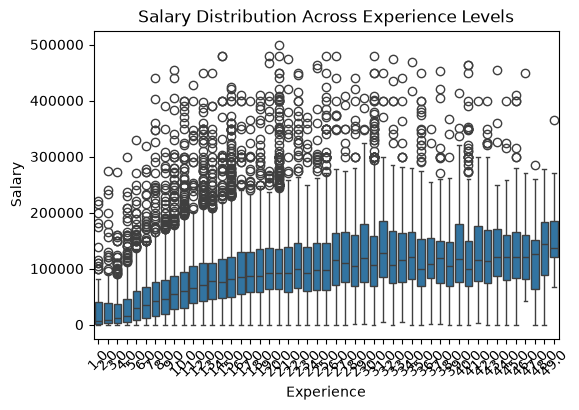

In [13]:
plot_box_salary_distribution(df)

The boxplot highlights that salaries vary significantly even for the same experience levels.

This confirms that experience alone is not a strong predictor of salary, and another factor must play a role.

## 5. Modeling
A linear regression model is trained to predict salary based on experience, work experience and education.

In [14]:
# Features and targets
X = df.drop("Salary", axis = 1)
y = df["Salary"]

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [15]:
# Train model
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 1733.7 , 894.06,11665.36,...,10023.81,-9740.24,-2236.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Experience','WorkExperience', 'Education_Bachelor’s degree (B.A., B.S., B.Eng., etc.)',..., 'Education_Professional degree (JD, MD, Ph.D, Ed.D, etc.)', 'Education_Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)', 'Education_Some college/university study without earning a degree']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.905e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


## 6.Evaluation
The model performance is evaluated using the R2 score.

In [16]:
# Predictions
y_pred = model.predict(X_test)

In [17]:
# Evaluate model
score = r2_score(Y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.1483083469221812


The model achieves an R2 score of around 0.15, meaning it explains about 15% of the variation in the salary.

This indicates that important factors influencing salary are missing from the model.

## 7. Prediction

A prediction is made for a sample developer to demonstrate how the model works.

Experience: 14.0 years
Predicted Salary: 78111.49952356082


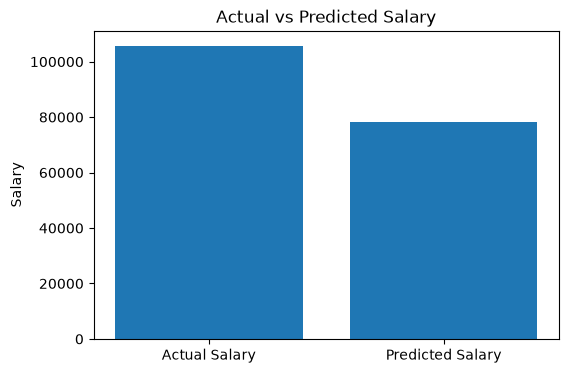

In [18]:
# Prediction scenario
sample = X.iloc[0:1]
actual_value = Y_test.iloc[0]
predicted_value = model.predict(sample)[0]

print(f"Experience: {X.iloc[0]['Experience']} years")
print("Predicted Salary:", predicted_value)

# Create comparsion plot
plt.figure(figsize=(6,4))

labels = ["Actual Salary", "Predicted Salary"]
values = [actual_value, predicted_value]

plt.bar(labels, values)
plt.title("Actual vs Predicted Salary")
plt.ylabel("Salary")

plt.show()

This visualization compares the actual salary and the predicted salary for a sample developer.
The model provides a reasonable estimate, but there ist still a noticeable difference between the predicted and actual value. This reflects the low overall model accuracy and shows that additional factors influence salary beyond the variables used in the model.

# 8. Conclusion

The analysis shows that experience alone is not enough to explain developer salaries.
While it has some influence, salary varies significantly across individuals.

The low model accuracy confirms that many important factors, such as location or specialization, are not included in the dataset.

This project demonstrates how data analysis and machine learning can be used to uncover insights, even when the data is complex and incomplete.